# Experiment 7.3.3 — Affine Linear to LIF Substitution

Analysis-only notebook. It reads finalized Exp7.3.3 artifacts and does not train models or submit jobs.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start=Path.cwd()):
    cur = start.resolve()
    for candidate in (cur, *cur.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root')

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_7_3_3_affine_lif_substitution' / 'affine_lif_substitution_v1'
manifest = json.loads((ROOT / 'manifest.json').read_text())
runs = pd.read_csv(ROOT / 'method_runs.csv')
summary = pd.read_csv(ROOT / 'method_summary.csv')
contrasts = pd.read_csv(ROOT / 'contrast_summary.csv')
checks = pd.read_csv(ROOT / 'p7_reproduction_and_charge_checks.csv')
manifest


{'architecture': '234x234',
 'backbone_objectives': ['tsce', 'wcce'],
 'experiment_id': 'experiment_7_3_3_affine_lif_substitution',
 'if_beta': 1.0,
 'lif_beta': 0.5,
 'logical_runs': 6,
 'methods': ['analog_affine',
  'analog_w_only',
  'lif_beta05_w_only',
  'lif_beta05_bias_start',
  'lif_beta05_bias_end',
  'if_beta1_bias_start_count',
  'if_beta1_bias_start_charge',
  'if_beta1_bias_end_count',
  'if_beta1_bias_end_charge'],
 'notes': 'P7 affine parameters are reconstructed at the already-selected Exp7.3.2 C. All readouts use the same recovered W and effective sequence-level intercept. No gain, threshold, beta, or parameter re-optimization is performed.',
 'output_cap': 1,
 'protocol_version': 'affine_lif_substitution_v1',
 'seeds': [11, 23, 37],
 'source_case': 'P7_wholecount_scale_center_bias',
 'threshold': 0.5}

## P7 parameter reconstruction and beta=1 charge checks

Every row should show zero prediction mismatch and near-zero charge error.


In [2]:
checks


,seed,backbone_objective,selected_C,source_p7_test_ba,reconstructed_p7_test_ba,max_abs_ba_delta,max_prediction_mismatch_count,max_abs_score_error,if_start_charge_max_abs_error,if_end_charge_max_abs_error
0,11,tsce,0.01,0.615174,0.615174,0.0,0,7.105427e-15,3.552714e-15,4.440892e-15
1,23,tsce,0.10,0.559415,0.559415,0.0,0,1.065814e-14,8.881784e-15,9.769963e-15
2,37,tsce,0.10,0.613776,0.613776,0.0,0,1.065814e-14,7.105427e-15,7.105427e-15
3,11,wcce,0.01,0.575830,0.575830,0.0,0,8.881784e-15,4.440892e-15,4.440892e-15
4,23,wcce,0.01,0.587870,0.587870,0.0,0,8.881784e-15,4.884981e-15,4.440892e-15
5,37,wcce,0.01,0.595121,0.595121,0.0,0,8.881784e-15,6.217249e-15,6.217249e-15


## Test balanced accuracy

`analog_affine` is the recovered Exp7.3.2 P7 ceiling. All LIF/IF methods reuse exactly the same recovered W and effective sequence-level intercept; only the output dynamics and bias injection timing change.


In [3]:
cols = [
    'backbone_objective', 'method',
    'test_ba_mean', 'test_ba_std',
    'source_p7_test_ba_mean', 'delta_vs_affine_p7_pp_mean',
]
summary[cols]


,backbone_objective,method,test_ba_mean,test_ba_std,source_p7_test_ba_mean,delta_vs_affine_p7_pp_mean
0,tsce,analog_affine,0.596121,0.031797,0.596121,0.000000
1,tsce,analog_w_only,0.425884,0.030493,0.596121,-17.023763
2,tsce,if_beta1_bias_end_charge,0.596121,0.031797,0.596121,0.000000
3,tsce,if_beta1_bias_end_count,0.447355,0.040408,0.596121,-14.876651
4,tsce,if_beta1_bias_start_charge,0.596121,0.031797,0.596121,0.000000
5,tsce,if_beta1_bias_start_count,0.455500,0.098815,0.596121,-14.062165
6,tsce,lif_beta05_bias_end,0.083333,0.000000,0.596121,-51.278814
7,tsce,lif_beta05_bias_start,0.083333,0.000000,0.596121,-51.278814
8,tsce,lif_beta05_w_only,0.087302,0.006873,0.596121,-50.881988
9,wcce,analog_affine,0.586273,0.009744,0.586273,0.000000


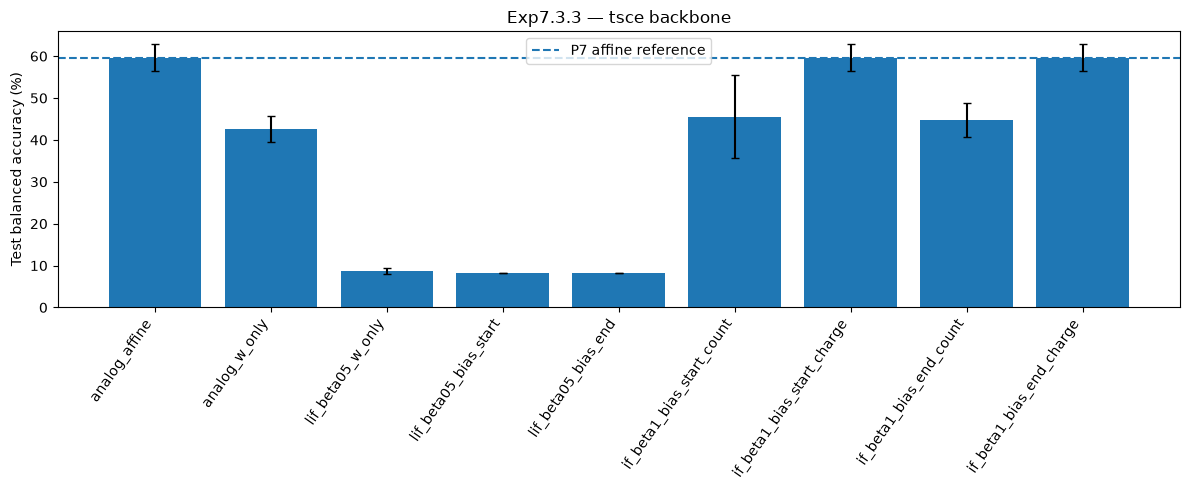

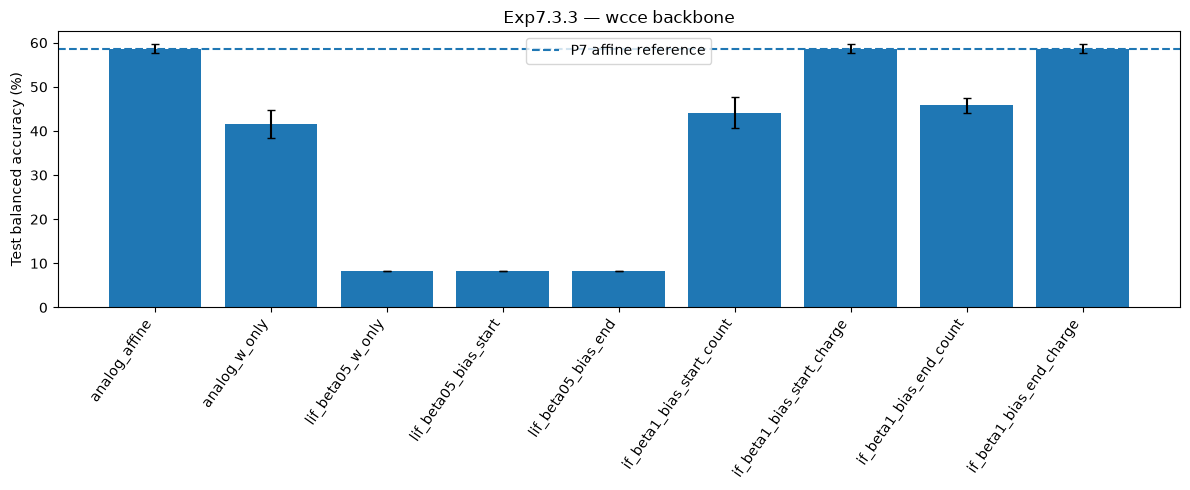

In [4]:
method_order = manifest['methods']
for backbone in manifest['backbone_objectives']:
    view = summary[summary.backbone_objective == backbone].set_index('method').reindex(method_order)
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(view))
    ax.bar(x, 100 * view.test_ba_mean.to_numpy(), yerr=100 * view.test_ba_std.fillna(0).to_numpy(), capsize=3)
    ax.axhline(100 * view.source_p7_test_ba_mean.iloc[0], linestyle='--', label='P7 affine reference')
    ax.set_xticks(x)
    ax.set_xticklabels(view.index, rotation=55, ha='right')
    ax.set_ylabel('Test balanced accuracy (%)')
    ax.set_title(f'Exp7.3.3 — {backbone} backbone')
    ax.legend()
    fig.tight_layout()
    plt.show()


## Mechanism contrasts

Key contrasts isolate removal of the affine offset, LIF realization loss, start/end one-shot bias benefit, and the beta=1 charge-preserving control.


In [5]:
contrasts.sort_values(['backbone_objective', 'contrast'])


,contrast,backbone_objective,delta_pp_count,delta_pp_mean,delta_pp_std
0,analog_w_only_minus_affine,tsce,3,-17.023763,4.175165
2,if_end_charge_minus_affine,tsce,3,0.000000,0.000000
4,if_end_count_minus_affine,tsce,3,-14.876651,2.448405
6,if_start_charge_minus_affine,tsce,3,0.000000,0.000000
8,if_start_count_minus_affine,tsce,3,-14.062165,11.175352
10,lif_end_minus_affine,tsce,3,-51.278814,3.179651
12,lif_end_minus_start,tsce,3,0.000000,0.000000
14,lif_end_minus_w_only,tsce,3,-0.396825,0.687322
16,lif_start_minus_affine,tsce,3,-51.278814,3.179651
18,lif_start_minus_w_only,tsce,3,-0.396825,0.687322
